# VoltRelay Energy: Data-Driven Analysis of an EV Battery-Swapping Network

## Project Overview

This project analyzes EV battery-swapping operations across six Indian
cities: Bengaluru, Delhi NCR, Hyderabad, Pune, Mumbai, and Jaipur.

The objective is to evaluate network performance, identify operational
challenges, understand customer experience, and develop data-driven
recommendations to support business decisions.

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb
import gc

print("All libraries imported successfully!")
print("Pandas version:", pd.__version__)
print("DuckDB version:", duckdb.__version__)

All libraries imported successfully!
Pandas version: 3.0.3
DuckDB version: 1.5.5


In [28]:
%pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [29]:
import os

DATA_DIR = r"D:\projects\Gradient_Hackathon\Hackathon Data Set _ Gradient"

print("Dataset folder exists:", os.path.exists(DATA_DIR))

Dataset folder exists: True


In [30]:
SWAP_FILE = os.path.join(DATA_DIR, "swap_events.csv")

In [31]:
import duckdb

con = duckdb.connect()

In [32]:
# Load City Daily Context

CONTEXT_FILE = os.path.join(
    DATA_DIR, "city_daily_context.csv"
).replace("\\", "/")

con.execute(f"""
    CREATE OR REPLACE VIEW city_context AS
    SELECT *
    FROM read_csv_auto('{CONTEXT_FILE}', header=TRUE)
""")

# Check columns and data types
display(con.execute("""
    DESCRIBE city_context
""").df())

,column_name,column_type,null,key,default,extra
0,city,VARCHAR,YES,None,None,None
1,date,DATE,YES,None,None,None
2,max_temp_c,DOUBLE,YES,None,None,None
3,min_temp_c,DOUBLE,YES,None,None,None
4,rainfall_mm,DOUBLE,YES,None,None,None
5,heat_alert,BOOLEAN,YES,None,None,None
6,flood_disruption,BOOLEAN,YES,None,None,None
7,festival_or_event,VARCHAR,YES,None,None,None
8,is_public_holiday,BOOLEAN,YES,None,None,None
9,grid_outage_hours,DOUBLE,YES,None,None,None


In [33]:
# City Daily Context Summary

context_summary = con.execute("""
    SELECT
        city,
        COUNT(*) AS total_days,
        ROUND(AVG(max_temp_c), 2) AS avg_max_temp,
        ROUND(AVG(rainfall_mm), 2) AS avg_rainfall,
        SUM(CASE WHEN heat_alert THEN 1 ELSE 0 END) AS heat_alert_days,
        SUM(CASE WHEN flood_disruption THEN 1 ELSE 0 END) AS flood_days,
        SUM(CASE WHEN is_public_holiday THEN 1 ELSE 0 END) AS holidays,
        ROUND(SUM(grid_outage_hours), 2) AS total_grid_outage_hours,
        SUM(CASE WHEN competitor_promo_active THEN 1 ELSE 0 END)
            AS competitor_promo_days,
        SUM(CASE WHEN ecommerce_sale_event THEN 1 ELSE 0 END)
            AS ecommerce_sale_days
    FROM city_context
    GROUP BY city
    ORDER BY city
""").df()

display(context_summary)

,city,total_days,avg_max_temp,avg_rainfall,heat_alert_days,flood_days,holidays,total_grid_outage_hours,competitor_promo_days,ecommerce_sale_days
0,Bengaluru,547,24.62,4.71,0.0,0.0,3.0,44.8,43.0,10.0
1,Delhi NCR,547,25.27,5.17,62.0,0.0,3.0,58.1,0.0,10.0
2,Hyderabad,547,26.87,4.53,16.0,0.0,3.0,37.9,0.0,10.0
3,Jaipur,547,25.83,4.71,72.0,0.0,3.0,60.9,0.0,10.0
4,Mumbai,547,25.93,11.43,0.0,7.0,3.0,40.0,0.0,10.0
5,Pune,547,23.88,4.47,0.0,0.0,3.0,41.9,43.0,10.0


In [34]:
required_files = [
    "swap_events.csv",
    "station_hourly_status.csv",
    "riders.csv",
    "batteries.csv",
    "support_tickets.csv",
    "stations.csv",
    "city_daily_context.csv",
    "fleet_partners.csv"
]

for file in required_files:
    path = os.path.join(DATA_DIR, file)

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✅ {file}: {size_mb:.2f} MB")
    else:
        print(f"❌ Missing: {file}")

✅ swap_events.csv: 694.97 MB
✅ station_hourly_status.csv: 103.33 MB
✅ riders.csv: 2.00 MB
✅ batteries.csv: 0.60 MB
✅ support_tickets.csv: 6.23 MB
✅ stations.csv: 0.02 MB
✅ city_daily_context.csv: 0.21 MB
✅ fleet_partners.csv: 0.00 MB


In [35]:
import duckdb
import os

TEMP_DIR = os.path.join(DATA_DIR, "duckdb_temp")
os.makedirs(TEMP_DIR, exist_ok=True)

con = duckdb.connect()

con.execute("SET memory_limit = '3GB'")
con.execute("SET threads = 4")
con.execute(
    f"SET temp_directory = '{TEMP_DIR.replace(chr(92), '/')}'"
)

print("DuckDB configured successfully!")

DuckDB configured successfully!


In [36]:
con.execute(f"""
    CREATE OR REPLACE VIEW swap AS
    SELECT *
    FROM read_csv(
        '{SWAP_FILE.replace(chr(92), '/')}',
        delim = ',',
        header = TRUE,
        quote = '"',
        escape = '"',
        strict_mode = FALSE,
        ignore_errors = TRUE,
        sample_size = 10000
    )
""")

print("Swap events view created successfully!")

Swap events view created successfully!


In [37]:
result = con.execute("""
    SELECT COUNT(*) AS total_rows
    FROM swap
""").df()

print(result)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_rows
0     3877013


In [38]:
columns = con.execute("""
    DESCRIBE SELECT * FROM swap
""").df()

display(columns)

,column_name,column_type,null,key,default,extra
0,event_id,VARCHAR,YES,None,None,None
1,rider_id,VARCHAR,YES,None,None,None
2,station_id,VARCHAR,YES,None,None,None
3,event_ts,TIMESTAMP,YES,None,None,None
4,event_type,VARCHAR,YES,None,None,None
5,attempt_seq,BIGINT,YES,None,None,None
6,queue_wait_sec,BIGINT,YES,None,None,None
7,battery_in_id,VARCHAR,YES,None,None,None
8,battery_out_id,VARCHAR,YES,None,None,None
9,soc_in_pct,DOUBLE,YES,None,None,None


In [41]:
quality = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT event_id) AS unique_events,
        COUNT(*) - COUNT(DISTINCT event_id) AS duplicate_events,
        COUNT(*) FILTER (WHERE event_ts IS NULL) AS missing_timestamps,
        COUNT(*) FILTER (WHERE rider_id IS NULL) AS missing_riders,
        COUNT(*) FILTER (WHERE station_id IS NULL) AS missing_stations
    FROM swap
""").df()

display(quality)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_events,duplicate_events,missing_timestamps,missing_riders,missing_stations
0,3877013,3877013,0,0,0,0


In [42]:
# Validate swap data

data_validation = con.execute("""
    SELECT
        COUNT(*) FILTER (
            WHERE soc_in_pct < 0 OR soc_in_pct > 100
        ) AS invalid_soc_in,

        COUNT(*) FILTER (
            WHERE soc_out_pct < 0 OR soc_out_pct > 100
        ) AS invalid_soc_out,

        COUNT(*) FILTER (
            WHERE soh_in_pct < 0 OR soh_in_pct > 100
        ) AS invalid_soh_in,

        COUNT(*) FILTER (
            WHERE soh_out_pct < 0 OR soh_out_pct > 100
        ) AS invalid_soh_out,

        COUNT(*) FILTER (
            WHERE queue_wait_sec < 0
        ) AS invalid_wait_time

    FROM swap
""").df()

display(data_validation)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,invalid_soc_in,invalid_soc_out,invalid_soh_in,invalid_soh_out,invalid_wait_time
0,0,3698,3356,2799,0


In [43]:
outcomes = con.execute("""
    SELECT
        event_type,
        COUNT(*) AS total_attempts,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
            2
        ) AS percentage
    FROM swap
    GROUP BY event_type
    ORDER BY total_attempts DESC
""").df()

display(outcomes)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,total_attempts,percentage
0,swap_completed,3645809,94.04
1,failed_no_charged_battery,134389,3.47
2,abandoned_queue,68533,1.77
3,cancelled_by_rider,16712,0.43
4,failed_system_error,11570,0.30


In [44]:
monthly = con.execute("""
    SELECT
        DATE_TRUNC('month', event_ts) AS month,
        COUNT(*) AS total_attempts,
        COUNT(*) FILTER (
            WHERE event_type = 'swap_completed'
        ) AS completed_swaps,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE event_type IN (
                    'failed_no_charged_battery',
                    'failed_system_error'
                )
            ) / COUNT(*),
            2
        ) AS operational_failure_pct
    FROM swap
    GROUP BY 1
    ORDER BY 1
""").df()

display(monthly)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,total_attempts,completed_swaps,operational_failure_pct
0,2024-01-01,110348,105490,2.73
1,2024-02-01,111531,106582,2.71
2,2024-03-01,123900,118444,2.69
3,2024-04-01,131818,122836,4.38
4,2024-05-01,146278,128328,8.04
5,2024-06-01,148888,133743,6.66
6,2024-07-01,158688,151824,2.64
7,2024-08-01,172295,164931,2.57
8,2024-09-01,195885,187302,2.71
9,2024-10-01,229901,219838,2.67


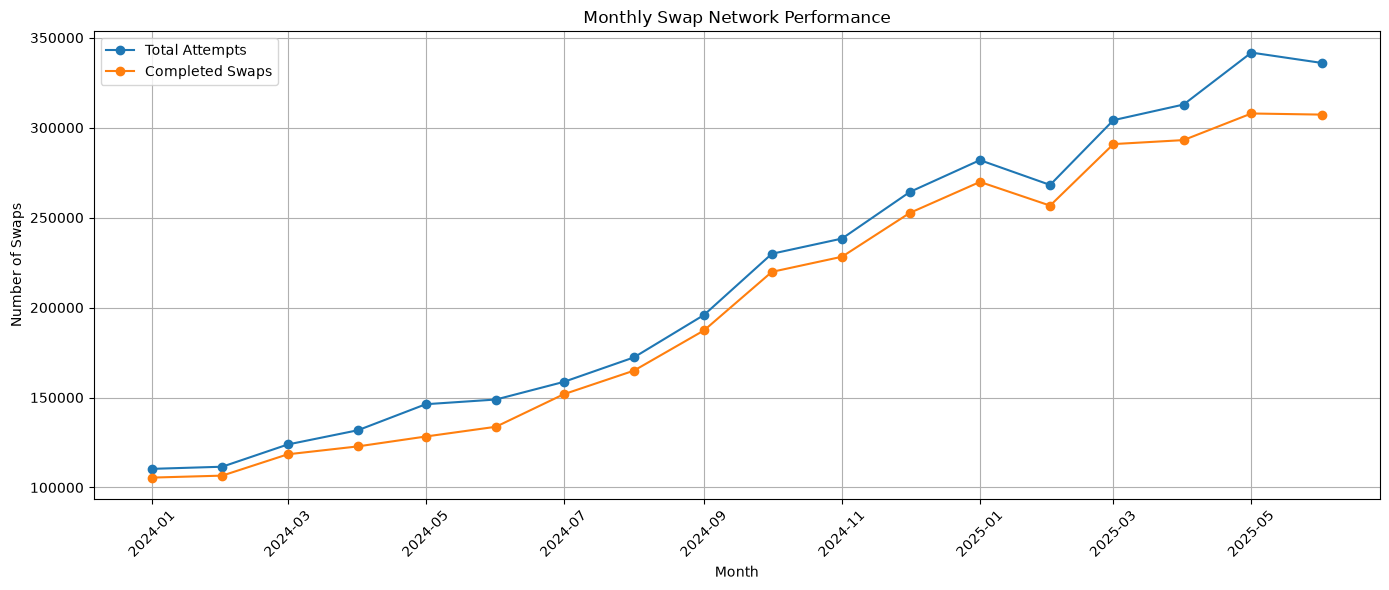

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly["month"],
    monthly["total_attempts"],
    marker="o",
    label="Total Attempts"
)

plt.plot(
    monthly["month"],
    monthly["completed_swaps"],
    marker="o",
    label="Completed Swaps"
)

plt.title("Monthly Swap Network Performance")
plt.xlabel("Month")
plt.ylabel("Number of Swaps")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
STATION_FILE = os.path.join(DATA_DIR, "stations.csv").replace("\\", "/")

con.execute(f"""
    CREATE OR REPLACE VIEW stations AS
    SELECT *
    FROM read_csv_auto('{STATION_FILE}', header=TRUE)
""")

print("Station data connected successfully!")

Station data connected successfully!


In [47]:
# Load station hourly status data
STATION_STATUS_FILE = os.path.join(
    DATA_DIR, "station_hourly_status.csv"
).replace("\\", "/")

con.execute(f"""
    CREATE OR REPLACE VIEW station_status AS
    SELECT *
    FROM read_csv_auto(
        '{STATION_STATUS_FILE}',
        header=TRUE
    )
""")

# Check the dataset structure
display(con.execute("""
    DESCRIBE station_status
""").df())

,column_name,column_type,null,key,default,extra
0,station_id,VARCHAR,YES,None,None,None
1,hour_start,TIMESTAMP,YES,None,None,None
2,charged_2w_avg,DOUBLE,YES,None,None,None
3,charged_2w_min,BIGINT,YES,None,None,None
4,charged_3w_min,BIGINT,YES,None,None,None
5,packs_charging,BIGINT,YES,None,None,None
6,packs_quarantined,BIGINT,YES,None,None,None
7,chargers_online,BIGINT,YES,None,None,None
8,ambient_temp_c,DOUBLE,YES,None,None,None
9,cabinet_temp_c,DOUBLE,YES,None,None,None


In [48]:
# Station Availability Analysis

station_availability = con.execute("""
    SELECT
        telemetry_status,
        COUNT(*) AS total_records,
        ROUND(AVG(chargers_online), 2) AS avg_chargers_online,
        ROUND(AVG(outage_minutes), 2) AS avg_outage_minutes,
        ROUND(AVG(charged_2w_min), 2) AS avg_2w_battery_stock,
        ROUND(AVG(charged_3w_min), 2) AS avg_3w_battery_stock
    FROM station_status
    GROUP BY telemetry_status
    ORDER BY total_records DESC
""").df()

display(station_availability)

,telemetry_status,total_records,avg_chargers_online,avg_outage_minutes,avg_2w_battery_stock,avg_3w_battery_stock
0,ok,1441341,14.74,0.01,7.21,2.54
1,partial,36987,15.06,0.01,7.40,2.69
2,missing,9384,15.40,0.01,NaN,NaN


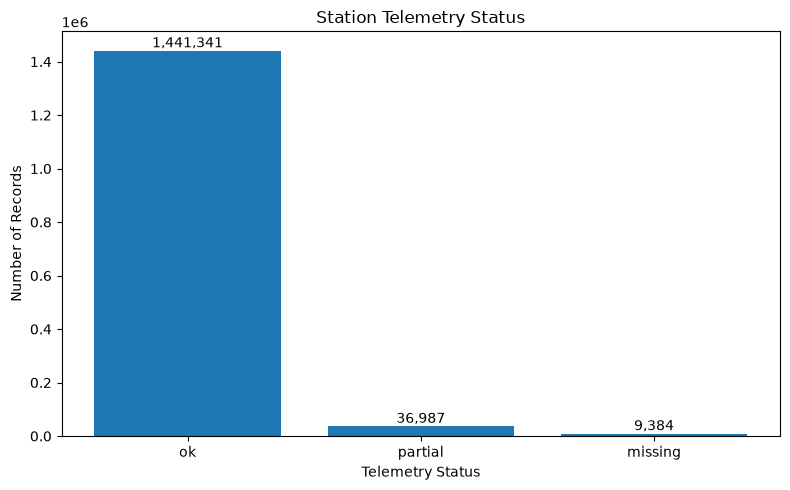

In [49]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    station_availability["telemetry_status"],
    station_availability["total_records"]
)

plt.title("Station Telemetry Status")
plt.xlabel("Telemetry Status")
plt.ylabel("Number of Records")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [50]:
# Analyze station outages

outage_analysis = con.execute("""
    SELECT
        station_id,
        COUNT(*) AS total_hours,
        SUM(outage_minutes) AS total_outage_minutes,
        ROUND(AVG(chargers_online), 2) AS avg_chargers_online
    FROM station_status
    WHERE telemetry_status = 'ok'
    GROUP BY station_id
    ORDER BY total_outage_minutes DESC
    LIMIT 10
""").df()

display(outage_analysis)

,station_id,total_hours,total_outage_minutes,avg_chargers_online
0,STN-MUM-118,11717,1020.0,7.99
1,STN-MUM-122,12999,720.0,11.98
2,STN-MUM-112,13011,600.0,15.98
3,STN-MUM-111,13004,540.0,7.99
4,STN-MUM-117,12558,540.0,15.99
5,STN-MUM-116,11731,480.0,21.99
6,STN-MUM-121,12988,480.0,15.98
7,STN-DEL-038,13002,420.0,7.98
8,STN-MUM-120,12632,420.0,17.98
9,STN-DEL-037,12996,360.0,15.98


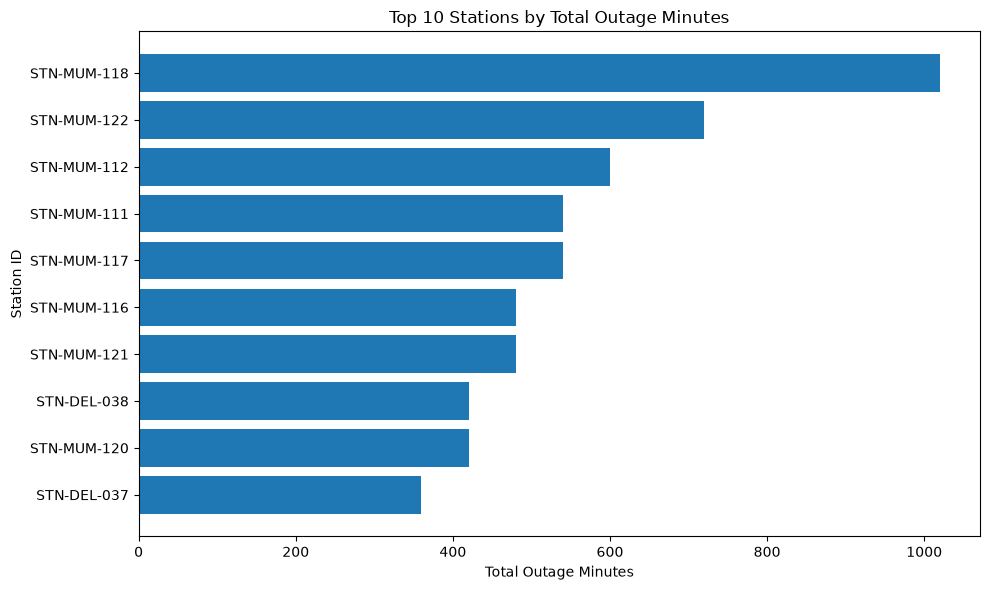

In [51]:
# Top 10 Stations by Total Outage Minutes

plt.figure(figsize=(10, 6))

plt.barh(
    outage_analysis["station_id"],
    outage_analysis["total_outage_minutes"]
)

plt.title("Top 10 Stations by Total Outage Minutes")
plt.xlabel("Total Outage Minutes")
plt.ylabel("Station ID")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [52]:
city_analysis = con.execute("""
    SELECT
        s.city,
        COUNT(*) AS total_attempts,
        COUNT(*) FILTER (
            WHERE w.event_type = 'swap_completed'
        ) AS completed_swaps,
        COUNT(*) FILTER (
            WHERE w.event_type IN (
                'failed_no_charged_battery',
                'failed_system_error'
            )
        ) AS operational_failures,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE w.event_type IN (
                    'failed_no_charged_battery',
                    'failed_system_error'
                )
            ) / COUNT(*),
            2
        ) AS failure_rate_pct
    FROM swap w
    JOIN stations s
        ON w.station_id = s.station_id
    GROUP BY s.city
    ORDER BY failure_rate_pct DESC
""").df()

display(city_analysis)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,city,total_attempts,completed_swaps,operational_failures,failure_rate_pct
0,Jaipur,487634,449366,24677,5.06
1,Delhi NCR,768913,712385,36197,4.71
2,Hyderabad,711930,664312,30427,4.27
3,Pune,552910,525331,17127,3.10
4,Bengaluru,825327,787697,23090,2.80
5,Mumbai,530299,506718,14441,2.72


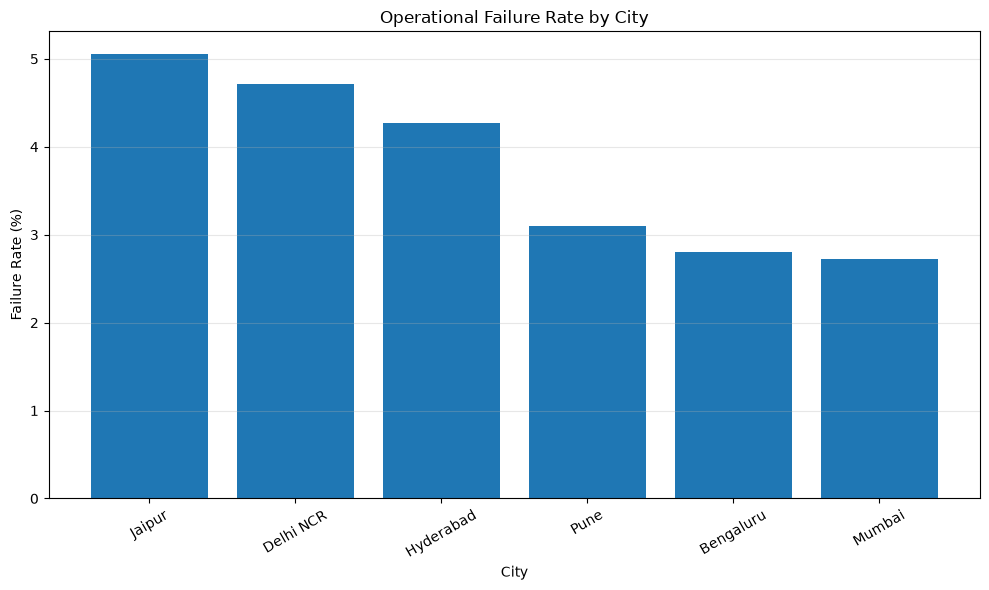

In [53]:
plt.figure(figsize=(10, 6))

plt.bar(
    city_analysis["city"],
    city_analysis["failure_rate_pct"]
)

plt.title("Operational Failure Rate by City")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
columns = con.execute("DESCRIBE swap").df()
print(columns["column_name"].tolist())

['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']


In [55]:
RIDERS_FILE = os.path.join(DATA_DIR, "riders.csv").replace("\\", "/")

con.execute(f"""
    CREATE OR REPLACE VIEW riders AS
    SELECT *
    FROM read_csv_auto('{RIDERS_FILE}', header=TRUE)
""")

print("Rider data connected successfully!")

Rider data connected successfully!


In [56]:
vehicle_analysis = con.execute("""
    SELECT
        r.vehicle_class,
        COUNT(*) AS total_attempts,
        COUNT(*) FILTER (
            WHERE s.event_type = 'swap_completed'
        ) AS completed_swaps,
        COUNT(*) FILTER (
            WHERE s.event_type IN (
                'failed_no_charged_battery',
                'failed_system_error'
            )
        ) AS operational_failures,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE s.event_type IN (
                    'failed_no_charged_battery',
                    'failed_system_error'
                )
            ) / COUNT(*),
            2
        ) AS failure_rate_pct
    FROM swap s
    JOIN riders r
        ON s.rider_id = r.rider_id
    GROUP BY r.vehicle_class
    ORDER BY failure_rate_pct DESC
""").df()

display(vehicle_analysis)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,vehicle_class,total_attempts,completed_swaps,operational_failures,failure_rate_pct
0,3W,424017,380134,28394,6.7
1,2W,3452996,3265675,117565,3.4


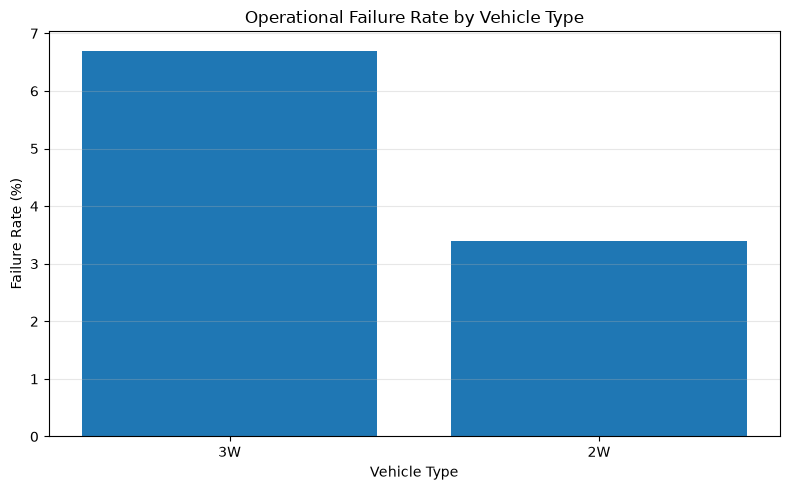

In [57]:
plt.figure(figsize=(8, 5))

plt.bar(
    vehicle_analysis["vehicle_class"],
    vehicle_analysis["failure_rate_pct"]
)

plt.title("Operational Failure Rate by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Failure Rate (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
city_vehicle = con.execute("""
    SELECT
        st.city,
        r.vehicle_class,
        COUNT(*) AS total_attempts,
        COUNT(*) FILTER (
            WHERE s.event_type IN (
                'failed_no_charged_battery',
                'failed_system_error'
            )
        ) AS failures,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE s.event_type IN (
                    'failed_no_charged_battery',
                    'failed_system_error'
                )
            ) / COUNT(*),
            2
        ) AS failure_rate_pct
    FROM swap s
    JOIN stations st
        ON s.station_id = st.station_id
    JOIN riders r
        ON s.rider_id = r.rider_id
    GROUP BY st.city, r.vehicle_class
    ORDER BY st.city, r.vehicle_class
""").df()

display(city_vehicle)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,city,vehicle_class,total_attempts,failures,failure_rate_pct
0,Bengaluru,2W,734440,17689,2.41
1,Bengaluru,3W,90887,5401,5.94
2,Delhi NCR,2W,690981,30447,4.41
3,Delhi NCR,3W,77932,5750,7.38
4,Hyderabad,2W,639787,25171,3.93
5,Hyderabad,3W,72143,5256,7.29
6,Jaipur,2W,436335,20531,4.71
7,Jaipur,3W,51299,4146,8.08
8,Mumbai,2W,462298,10564,2.29
9,Mumbai,3W,68001,3877,5.70


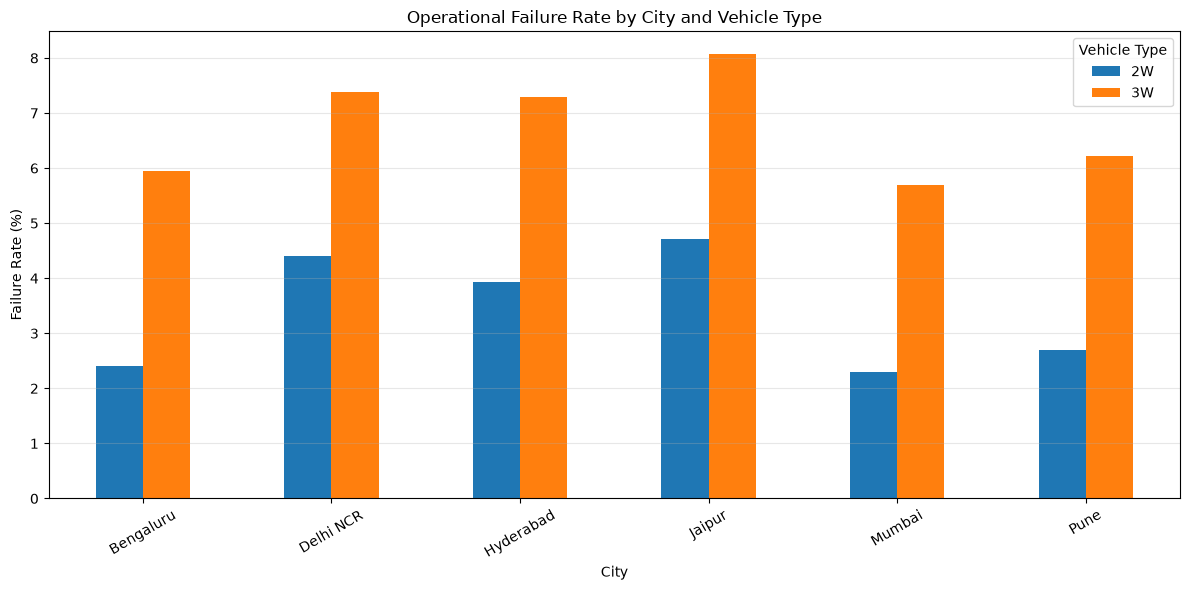

In [59]:
city_vehicle_pivot = city_vehicle.pivot(
    index="city",
    columns="vehicle_class",
    values="failure_rate_pct"
)

city_vehicle_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Operational Failure Rate by City and Vehicle Type")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)
plt.legend(title="Vehicle Type")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
failure_analysis = con.execute("""
    SELECT
        event_type,
        COUNT(*) AS total_events,
        ROUND(
            COUNT(*) * 100.0 /
            (SELECT COUNT(*) FROM swap),
            2
        ) AS percentage
    FROM swap
    GROUP BY event_type
    ORDER BY total_events DESC
""").df()

display(failure_analysis)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,total_events,percentage
0,swap_completed,3645809,94.04
1,failed_no_charged_battery,134389,3.47
2,abandoned_queue,68533,1.77
3,cancelled_by_rider,16712,0.43
4,failed_system_error,11570,0.30


In [61]:
failures_only = failure_analysis[
    failure_analysis["event_type"] != "swap_completed"
].copy()

display(failures_only)

,event_type,total_events,percentage
1,failed_no_charged_battery,134389,3.47
2,abandoned_queue,68533,1.77
3,cancelled_by_rider,16712,0.43
4,failed_system_error,11570,0.30


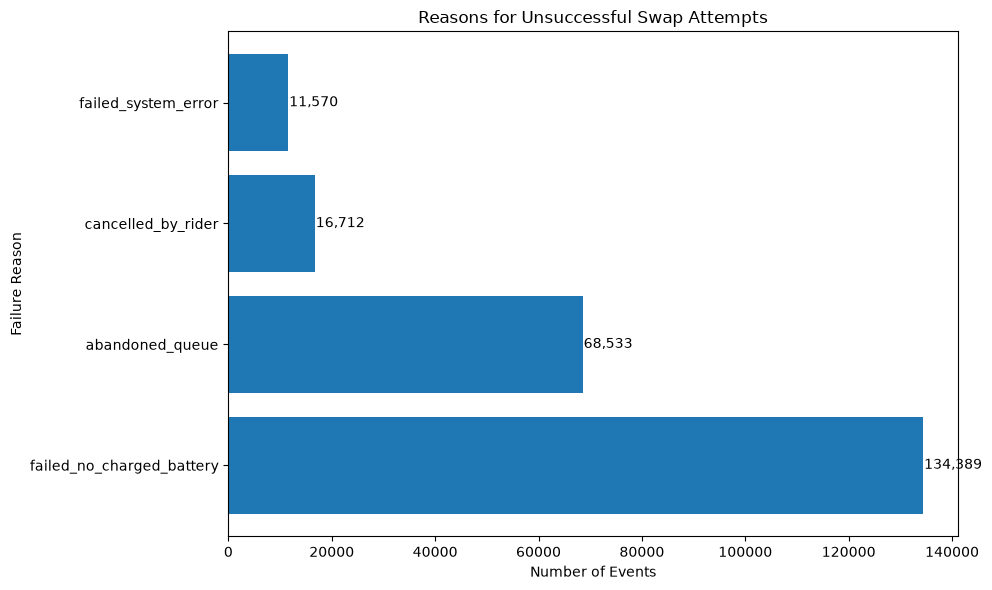

In [62]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    failures_only["event_type"],
    failures_only["total_events"]
)

for bar in bars:
    value = int(bar.get_width())
    plt.text(
        value + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center"
    )

plt.title("Reasons for Unsuccessful Swap Attempts")
plt.xlabel("Number of Events")
plt.ylabel("Failure Reason")
plt.tight_layout()
plt.show()

In [63]:
hourly_analysis = con.execute("""
    SELECT
        EXTRACT(HOUR FROM event_ts) AS hour,
        COUNT(*) AS total_attempts,
        COUNT(*) FILTER (
            WHERE event_type IN (
                'failed_no_charged_battery',
                'failed_system_error'
            )
        ) AS failures,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE event_type IN (
                    'failed_no_charged_battery',
                    'failed_system_error'
                )
            ) / COUNT(*),
            2
        ) AS failure_rate_pct
    FROM swap
    GROUP BY hour
    ORDER BY hour
""").df()

display(hourly_analysis)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,hour,total_attempts,failures,failure_rate_pct
0,0,23043,804,3.49
1,1,23482,791,3.37
2,2,25536,899,3.52
3,3,28822,908,3.15
4,4,31193,1002,3.21
5,5,28510,933,3.27
6,6,62020,2123,3.42
7,7,66889,2221,3.32
8,8,171129,6071,3.55
9,9,232933,8163,3.50


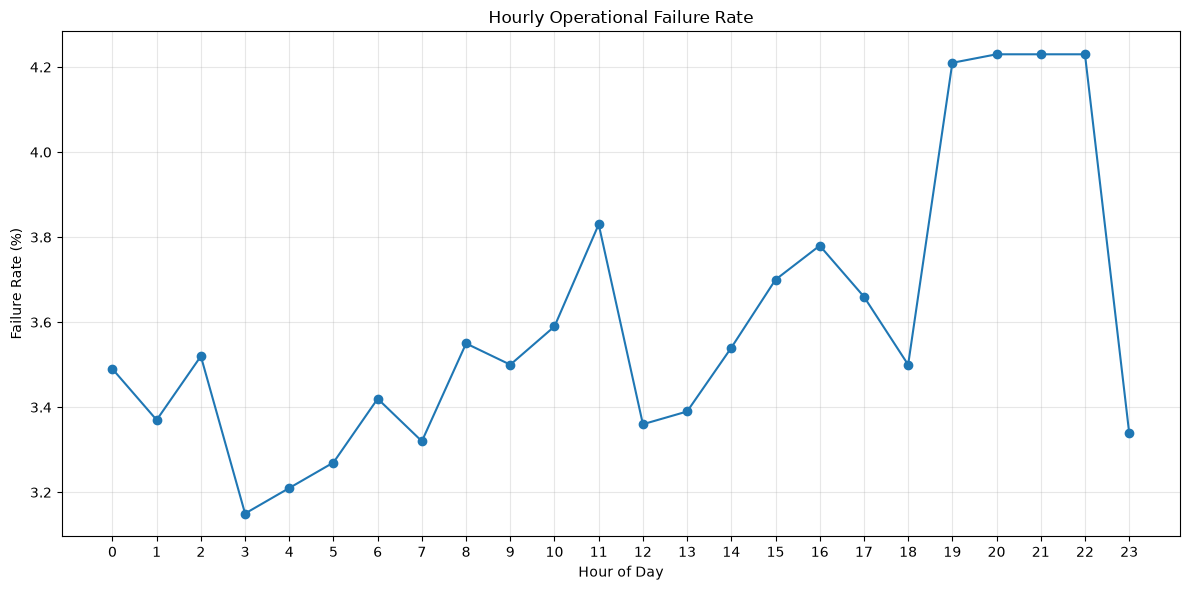

In [64]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_analysis["hour"],
    hourly_analysis["failure_rate_pct"],
    marker="o"
)

plt.title("Hourly Operational Failure Rate")
plt.xlabel("Hour of Day")
plt.ylabel("Failure Rate (%)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
BATTERY_FILE = os.path.join(DATA_DIR, "batteries.csv").replace("\\", "/")

con.execute(f"""
    CREATE OR REPLACE VIEW batteries AS
    SELECT *
    FROM read_csv_auto('{BATTERY_FILE}', header=TRUE)
""")

print("Battery data connected successfully!")

Battery data connected successfully!


In [66]:
battery_quality = con.execute("""
    SELECT *
    FROM batteries
    LIMIT 0
""").df()

battery_schema = con.execute("""
    DESCRIBE batteries
""").df()

display(battery_schema)

,column_name,column_type,null,key,default,extra
0,battery_id,VARCHAR,YES,None,None,None
1,pack_type,VARCHAR,YES,None,None,None
2,supplier,VARCHAR,YES,None,None,None
3,manufacturing_lot,VARCHAR,YES,None,None,None
4,manufacture_date,DATE,YES,None,None,None
5,commission_date,DATE,YES,None,None,None
6,rated_capacity_kwh,DOUBLE,YES,None,None,None
7,purchase_cost_inr,BIGINT,YES,None,None,None
8,initial_soh_pct,DOUBLE,YES,None,None,None
9,bms_firmware,VARCHAR,YES,None,None,None


In [67]:
battery_analysis = con.execute("""
    SELECT
        COUNT(*) AS total_batteries,
        ROUND(AVG(initial_soh_pct), 2) AS avg_initial_soh,
        ROUND(AVG(current_soh_pct), 2) AS avg_current_soh,
        ROUND(AVG(rated_capacity_kwh), 2) AS avg_capacity_kwh,
        COUNT(*) FILTER (
            WHERE retired_date IS NOT NULL
        ) AS retired_batteries,
        COUNT(*) FILTER (
            WHERE current_soh_pct < 80
        ) AS batteries_below_80_soh
    FROM batteries
""").df()

display(battery_analysis)

,total_batteries,avg_initial_soh,avg_current_soh,avg_capacity_kwh,retired_batteries,batteries_below_80_soh
0,6500,99.19,76.61,2.51,1438,3502


In [68]:
battery_health = con.execute("""
    SELECT
        CASE
            WHEN current_soh_pct < 60 THEN 'Below 60%'
            WHEN current_soh_pct < 70 THEN '60-69%'
            WHEN current_soh_pct < 80 THEN '70-79%'
            WHEN current_soh_pct < 90 THEN '80-89%'
            ELSE '90-100%'
        END AS health_range,
        COUNT(*) AS battery_count
    FROM batteries
    WHERE current_soh_pct IS NOT NULL
    GROUP BY health_range
    ORDER BY health_range
""").df()

display(battery_health)

,health_range,battery_count
0,60-69%,921
1,70-79%,2064
2,80-89%,2998
3,Below 60%,517


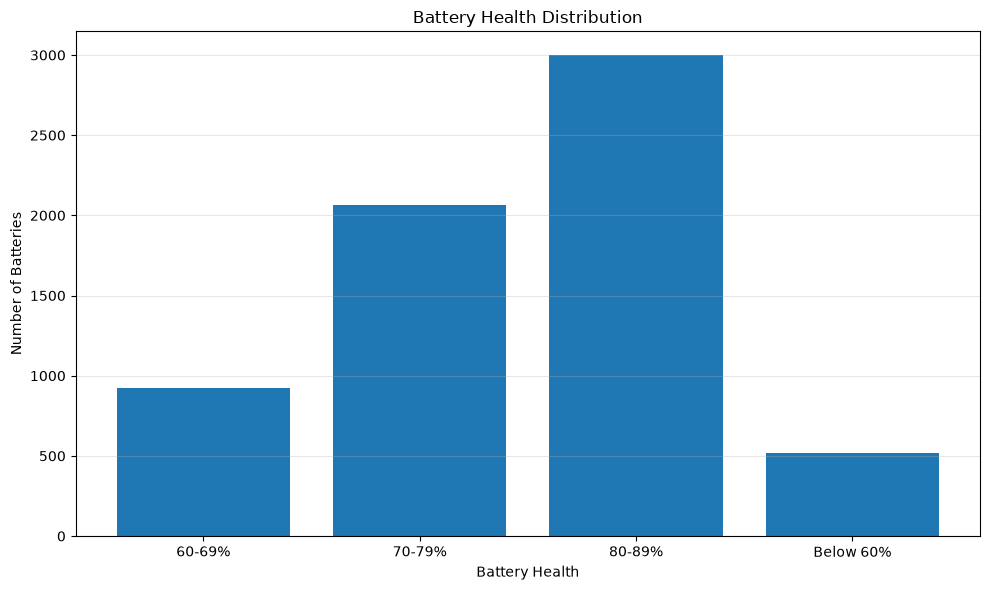

In [69]:
plt.figure(figsize=(10, 6))

plt.bar(
    battery_health["health_range"],
    battery_health["battery_count"]
)

plt.title("Battery Health Distribution")
plt.xlabel("Battery Health")
plt.ylabel("Number of Batteries")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
supplier_analysis = con.execute("""
    SELECT
        supplier,
        COUNT(*) AS total_batteries,
        ROUND(AVG(initial_soh_pct), 2) AS avg_initial_soh,
        ROUND(AVG(current_soh_pct), 2) AS avg_current_soh,
        COUNT(*) FILTER (
            WHERE retired_date IS NOT NULL
        ) AS retired_batteries
    FROM batteries
    GROUP BY supplier
    ORDER BY avg_current_soh
""").df()

display(supplier_analysis)

,supplier,total_batteries,avg_initial_soh,avg_current_soh,retired_batteries
0,Kyron,1638,99.21,63.75,1438
1,Cellora,3555,99.18,80.93,0
2,Amptek,1307,99.19,81.01,0


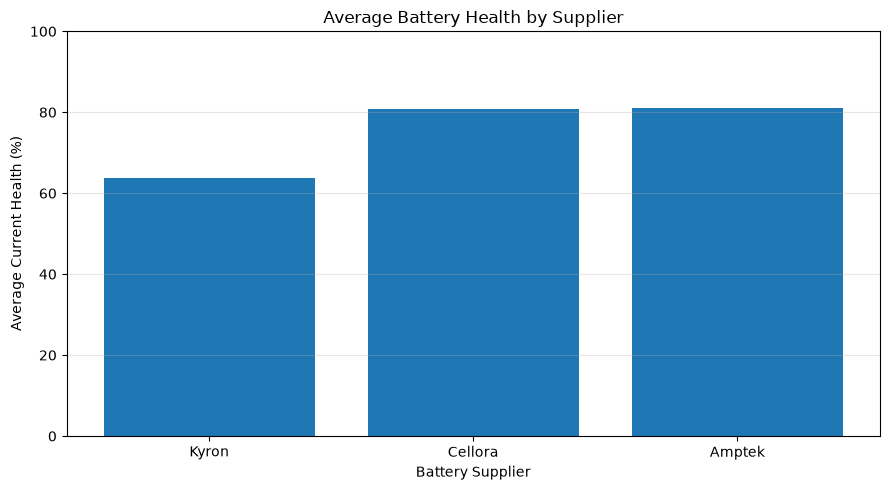

In [71]:
plt.figure(figsize=(9, 5))

plt.bar(
    supplier_analysis["supplier"],
    supplier_analysis["avg_current_soh"]
)

plt.title("Average Battery Health by Supplier")
plt.xlabel("Battery Supplier")
plt.ylabel("Average Current Health (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
battery_age_analysis = con.execute("""
    SELECT
        CASE
            WHEN date_diff('month', commission_date, DATE '2025-06-30') < 6
                THEN 'Under 6 months'
            WHEN date_diff('month', commission_date, DATE '2025-06-30') < 12
                THEN '6-12 months'
            WHEN date_diff('month', commission_date, DATE '2025-06-30') < 18
                THEN '12-18 months'
            ELSE '18+ months'
        END AS battery_age,
        COUNT(*) AS battery_count,
        ROUND(AVG(current_soh_pct), 2) AS avg_current_soh
    FROM batteries
    WHERE commission_date IS NOT NULL
      AND current_soh_pct IS NOT NULL
    GROUP BY battery_age
    ORDER BY MIN(date_diff('month', commission_date, DATE '2025-06-30'))
""").df()

display(battery_age_analysis)

,battery_age,battery_count,avg_current_soh
0,Under 6 months,1213,81.57
1,6-12 months,2825,70.78
2,12-18 months,1140,80.96
3,18+ months,1322,80.78


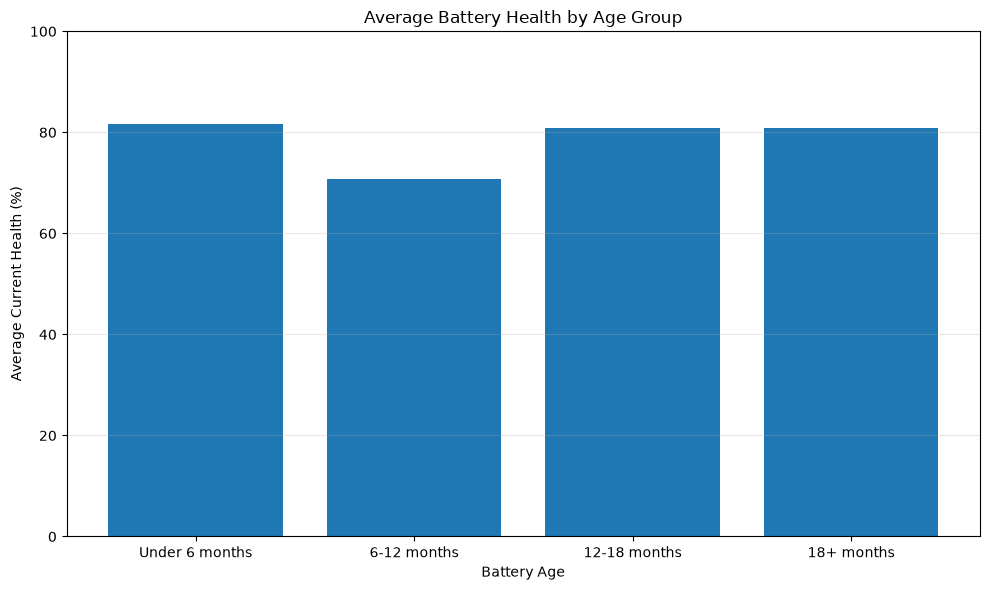

In [73]:
plt.figure(figsize=(10, 6))

plt.bar(
    battery_age_analysis["battery_age"],
    battery_age_analysis["avg_current_soh"]
)

plt.title("Average Battery Health by Age Group")
plt.xlabel("Battery Age")
plt.ylabel("Average Current Health (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
swap_battery_analysis = con.execute("""
    SELECT
        b.supplier,
        COUNT(*) AS completed_swaps,
        COUNT(DISTINCT s.battery_out_id) AS unique_batteries,
        ROUND(AVG(s.soh_out_pct), 2) AS avg_swap_battery_soh,
        ROUND(AVG(s.energy_to_recharge_kwh), 2)
            AS avg_recharge_energy_kwh
    FROM swap s
    JOIN batteries b
        ON s.battery_out_id = b.battery_id
    WHERE s.event_type = 'swap_completed'
      AND s.battery_out_id IS NOT NULL
    GROUP BY b.supplier
    ORDER BY avg_swap_battery_soh
""").df()

display(swap_battery_analysis)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,supplier,completed_swaps,unique_batteries,avg_swap_battery_soh,avg_recharge_energy_kwh
0,Kyron,657648,1638,82.02,2.07
1,Cellora,2188677,3555,89.81,2.09
2,Amptek,799484,1307,89.84,2.12


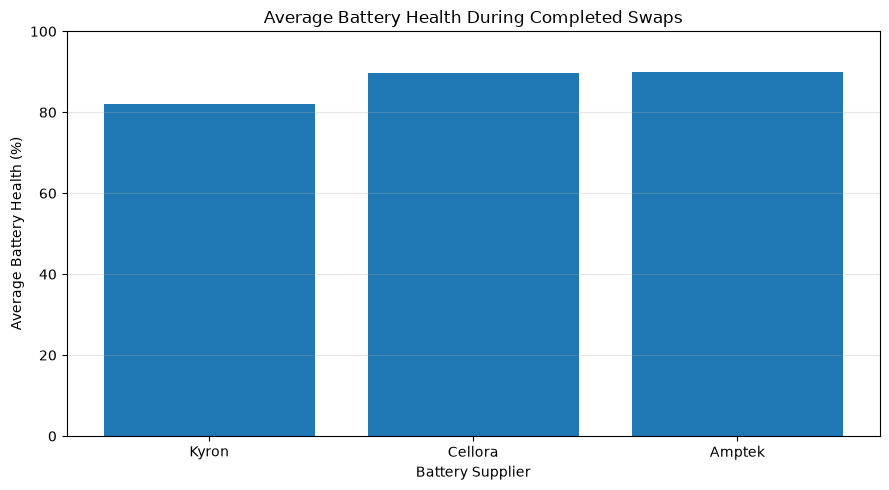

In [75]:
plt.figure(figsize=(9, 5))

plt.bar(
    swap_battery_analysis["supplier"],
    swap_battery_analysis["avg_swap_battery_soh"]
)

plt.title("Average Battery Health During Completed Swaps")
plt.xlabel("Battery Supplier")
plt.ylabel("Average Battery Health (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
pricing_analysis = con.execute("""
    SELECT
        tariff_code,
        COUNT(*) AS completed_swaps,
        ROUND(SUM(amount_charged_inr), 2) AS total_revenue,
        ROUND(AVG(amount_charged_inr), 2) AS avg_amount,
        ROUND(AVG(discount_inr), 2) AS avg_discount,
        ROUND(AVG(list_price_inr), 2) AS avg_list_price
    FROM swap
    WHERE event_type = 'swap_completed'
    GROUP BY tariff_code
    ORDER BY total_revenue DESC
""").df()

display(pricing_analysis)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,tariff_code,completed_swaps,total_revenue,avg_amount,avg_discount,avg_list_price
0,PARTNER,2409841,1.487535e+08,61.73,8.81,69.71
1,STD,1030037,6.820330e+07,66.21,0.00,66.21
2,PEAK,169833,1.401990e+07,82.55,0.00,67.55
3,OFFPEAK,36098,2.149346e+06,59.54,0.00,67.54


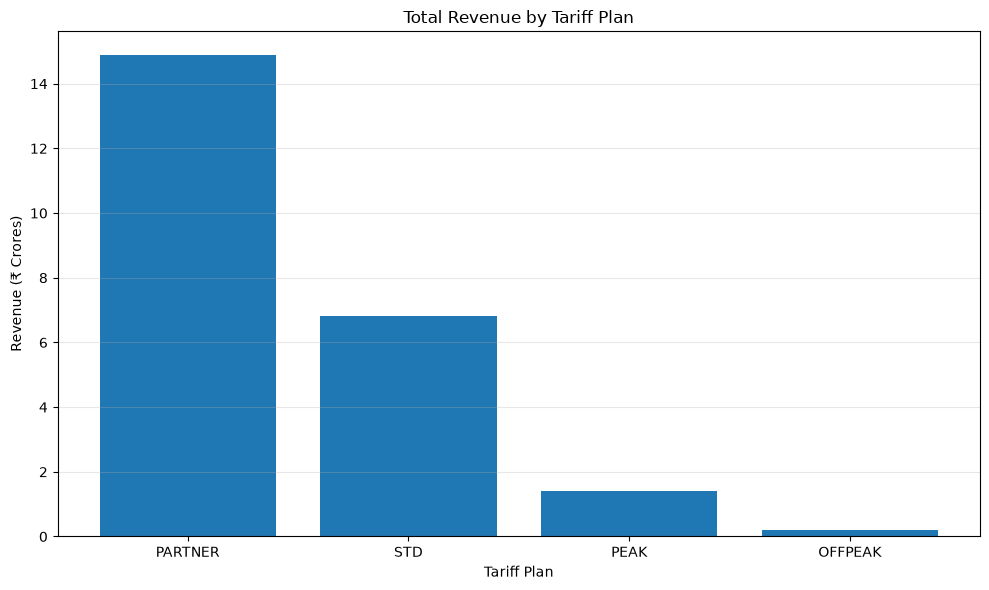

In [77]:
plt.figure(figsize=(10, 6))

plt.bar(
    pricing_analysis["tariff_code"],
    pricing_analysis["total_revenue"] / 10000000
)

plt.title("Total Revenue by Tariff Plan")
plt.xlabel("Tariff Plan")
plt.ylabel("Revenue (₹ Crores)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
PARTNER_FILE = os.path.join(DATA_DIR, "fleet_partners.csv").replace("\\", "/")

con.execute(f"""
    CREATE OR REPLACE VIEW fleet_partners AS
    SELECT *
    FROM read_csv_auto('{PARTNER_FILE}', header=TRUE)
""")

print("Fleet partner data connected successfully!")

Fleet partner data connected successfully!


In [79]:
partner_schema = con.execute("""
    DESCRIBE fleet_partners
""").df()

display(partner_schema)

,column_name,column_type,null,key,default,extra
0,partner_id,VARCHAR,YES,None,None,None
1,partner_name,VARCHAR,YES,None,None,None
2,partner_segment,VARCHAR,YES,None,None,None
3,vehicle_class,VARCHAR,YES,None,None,None
4,contract_type,VARCHAR,YES,None,None,None
5,contract_start_date,DATE,YES,None,None,None
6,discount_pct,DOUBLE,YES,None,None,None
7,amendment_date,DATE,YES,None,None,None
8,discount_pct_after_amendment,DOUBLE,YES,None,None,None
9,peak_surcharge_billable,VARCHAR,YES,None,None,None


In [80]:
RIDER_FILE = os.path.join(DATA_DIR, "riders.csv").replace("\\", "/")

con.execute(f"""
    CREATE OR REPLACE VIEW riders AS
    SELECT *
    FROM read_csv_auto('{RIDER_FILE}', header=TRUE)
""")

display(con.execute("DESCRIBE riders").df())

,column_name,column_type,null,key,default,extra
0,rider_id,VARCHAR,YES,None,None,None
1,partner_id,VARCHAR,YES,None,None,None
2,vehicle_class,VARCHAR,YES,None,None,None
3,vehicle_model,VARCHAR,YES,None,None,None
4,home_zone,VARCHAR,YES,None,None,None
5,signup_date,DATE,YES,None,None,None
6,signup_channel,VARCHAR,YES,None,None,None
7,plan_type,VARCHAR,YES,None,None,None
8,declared_shift,VARCHAR,YES,None,None,None
9,age_band,VARCHAR,YES,None,None,None


In [81]:
partner_analysis = con.execute("""
    SELECT
        fp.partner_name,
        fp.partner_segment,
        fp.vehicle_class,
        COUNT(*) AS total_attempts,
        COUNT(*) FILTER (
            WHERE s.event_type = 'swap_completed'
        ) AS completed_swaps,
        COUNT(*) FILTER (
            WHERE s.event_type IN (
                'failed_no_charged_battery',
                'failed_system_error'
            )
        ) AS operational_failures,
        ROUND(
            COUNT(*) FILTER (
                WHERE s.event_type IN (
                    'failed_no_charged_battery',
                    'failed_system_error'
                )
            ) * 100.0 / COUNT(*), 2
        ) AS operational_failure_pct,
        ROUND(
            SUM(CASE
                WHEN s.event_type = 'swap_completed'
                THEN s.amount_charged_inr
                ELSE 0
            END), 2
        ) AS total_revenue
    FROM swap s
    JOIN riders r
        ON s.rider_id = r.rider_id
    JOIN fleet_partners fp
        ON r.partner_id = fp.partner_id
    WHERE r.partner_id IS NOT NULL
    GROUP BY
        fp.partner_name,
        fp.partner_segment,
        fp.vehicle_class
    ORDER BY total_revenue DESC
""").df()

display(partner_analysis)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,partner_name,partner_segment,vehicle_class,total_attempts,completed_swaps,operational_failures,operational_failure_pct,total_revenue
0,FeastFly,food_delivery,2W,559823,526620,20947,3.74,32696006.00
1,ZipDrop,quick_commerce,2W,592069,557172,22056,3.73,29015711.20
2,ParcelNest,ecom_logistics,2W,319275,302506,10340,3.24,17113714.75
3,Swiggle Go,food_delivery,2W,256515,241689,9382,3.66,14336840.65
4,CargoTuk,cargo_3w,3W,149015,134085,9628,6.46,13333431.20
5,QuickCart,quick_commerce,2W,137831,129967,5035,3.65,8062439.00
6,RideMitra,bike_taxi,2W,127724,120695,4382,3.43,7569963.90
7,DabbaXpress,food_delivery,2W,99116,93376,3684,3.72,5953223.20
8,HaulKing,cargo_3w,3W,60434,54274,3949,6.53,5445913.90
9,UrbanErrand,bike_taxi,2W,88703,83854,3058,3.45,5322144.75


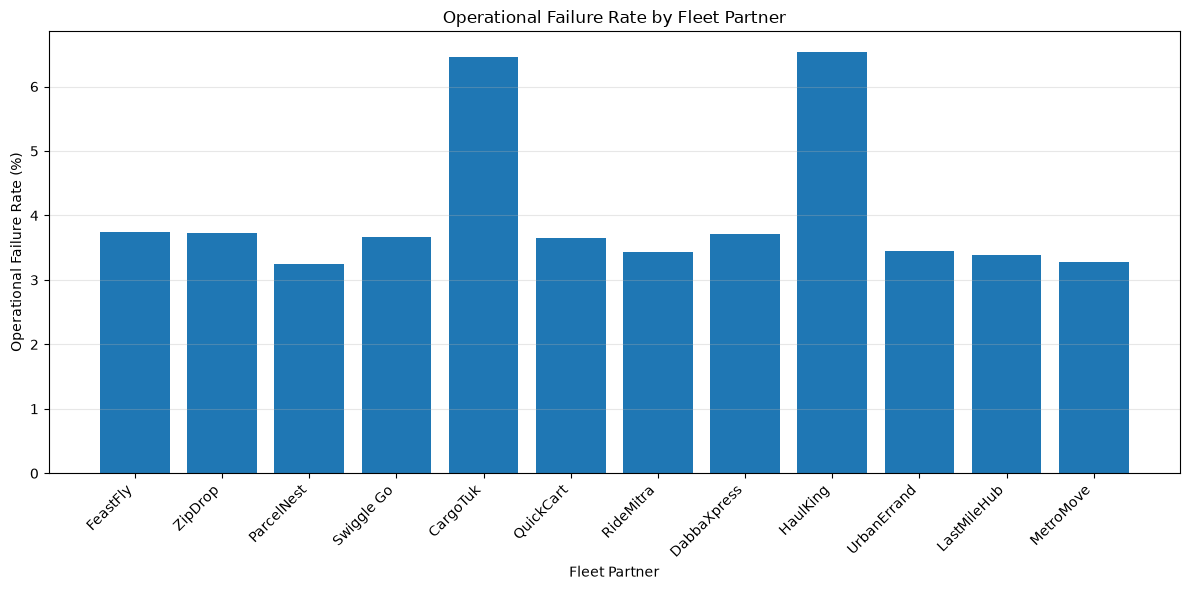

In [82]:
plt.figure(figsize=(12, 6))

plt.bar(
    partner_analysis["partner_name"],
    partner_analysis["operational_failure_pct"]
)

plt.title("Operational Failure Rate by Fleet Partner")
plt.xlabel("Fleet Partner")
plt.ylabel("Operational Failure Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [99]:
# ============================================================
# MONTHLY RIDER RETENTION ANALYSIS
# ============================================================

monthly_retention = con.execute("""
    WITH monthly_riders AS (
        SELECT DISTINCT
            rider_id,
            DATE_TRUNC('month', event_ts) AS month
        FROM swap
        WHERE event_type = 'swap_completed'
          AND rider_id IS NOT NULL
          AND event_ts IS NOT NULL
    ),

    latest_month AS (
        SELECT MAX(month) AS max_month
        FROM monthly_riders
    ),

    retention AS (
        SELECT
            a.month,
            COUNT(DISTINCT a.rider_id) AS active_riders,

            CASE
                WHEN a.month < lm.max_month
                THEN COUNT(DISTINCT b.rider_id)
                ELSE NULL
            END AS returning_riders

        FROM monthly_riders a
        CROSS JOIN latest_month lm

        LEFT JOIN monthly_riders b
            ON a.rider_id = b.rider_id
            AND b.month = a.month + INTERVAL '1 month'

        GROUP BY a.month, lm.max_month
    )

    SELECT
        month,
        active_riders,
        returning_riders,

        ROUND(
            returning_riders * 100.0
            / NULLIF(active_riders, 0),
            2
        ) AS next_month_retention_pct

    FROM retention
    ORDER BY month
""").df()

display(monthly_retention)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,active_riders,returning_riders,next_month_retention_pct
0,2024-01-01,4183,3881,92.78
1,2024-02-01,4449,4107,92.31
2,2024-03-01,4740,4315,91.03
3,2024-04-01,5080,4642,91.38
4,2024-05-01,5486,4952,90.27
5,2024-06-01,5834,5202,89.17
6,2024-07-01,6177,5688,92.08
7,2024-08-01,6714,6179,92.03
8,2024-09-01,7236,6582,90.96
9,2024-10-01,7941,7323,92.22


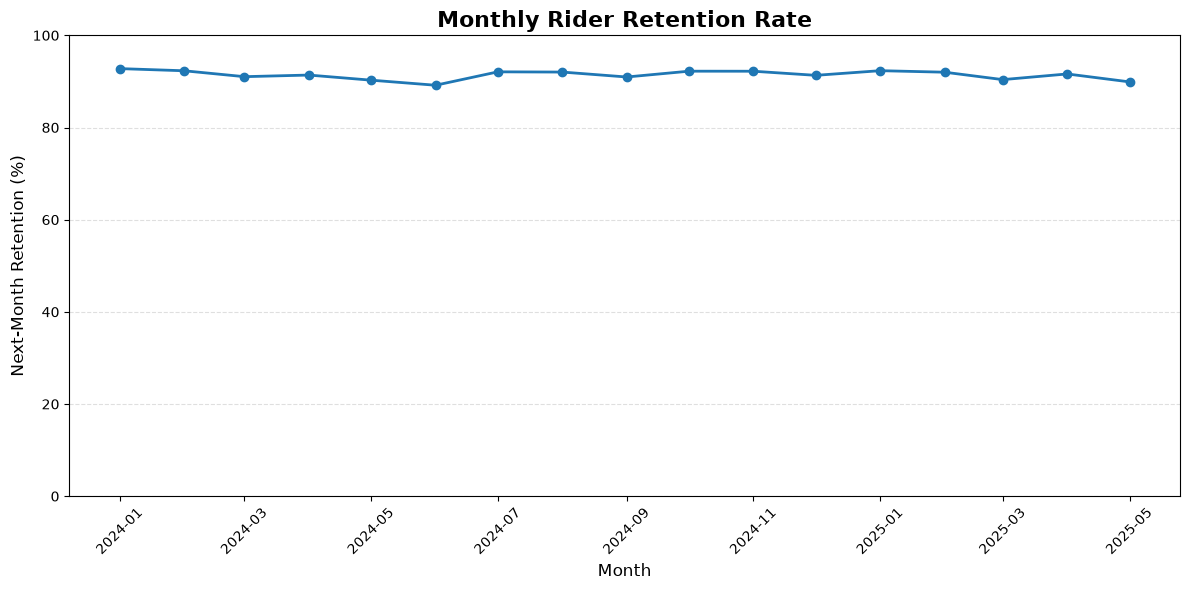

In [98]:
import matplotlib.pyplot as plt
import pandas as pd

# Sort data by month
retention_plot = monthly_retention.copy()
retention_plot["month"] = pd.to_datetime(retention_plot["month"])
retention_plot = retention_plot.sort_values("month")

# Remove the final month (June 2025)
retention_plot = retention_plot.iloc[:-1]

# Remove missing values
retention_plot = retention_plot.dropna(
    subset=["next_month_retention_pct"]
)

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    retention_plot["month"],
    retention_plot["next_month_retention_pct"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Rider Retention Rate",
          fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Next-Month Retention (%)", fontsize=12)

plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save as SVG
plt.savefig(
    "monthly_rider_retention.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [85]:
TICKET_FILE = os.path.join(DATA_DIR, "support_tickets.csv").replace("\\", "/")

con.execute(f"""
    CREATE OR REPLACE VIEW support_tickets AS
    SELECT *
    FROM read_csv_auto('{TICKET_FILE}', header=TRUE)
""")

print("Support ticket data loaded successfully!")

Support ticket data loaded successfully!


In [86]:
ticket_schema = con.execute("""
    DESCRIBE support_tickets
""").df()

display(ticket_schema)

,column_name,column_type,null,key,default,extra
0,ticket_id,VARCHAR,YES,None,None,None
1,rider_id,VARCHAR,YES,None,None,None
2,station_id,VARCHAR,YES,None,None,None
3,battery_id,VARCHAR,YES,None,None,None
4,created_ts,TIMESTAMP,YES,None,None,None
5,channel,VARCHAR,YES,None,None,None
6,category,VARCHAR,YES,None,None,None
7,rider_comment,VARCHAR,YES,None,None,None
8,priority,VARCHAR,YES,None,None,None
9,resolution_status,VARCHAR,YES,None,None,None


In [87]:
ticket_analysis = con.execute("""
    SELECT
        category,
        COUNT(*) AS total_tickets,
        ROUND(AVG(resolution_hours), 2)
            AS avg_resolution_hours,
        ROUND(AVG(csat_score), 2)
            AS avg_csat_score
    FROM support_tickets
    GROUP BY category
    ORDER BY total_tickets DESC
""").df()

display(ticket_analysis)

,category,total_tickets,avg_resolution_hours,avg_csat_score
0,no_battery_available,11647,15.96,3.60
1,other,9484,16.04,3.57
2,low_range,6636,15.99,3.53
3,app_issue,5787,15.89,3.54
4,long_queue,5731,15.84,3.51
5,billing_dispute,4715,15.91,3.57


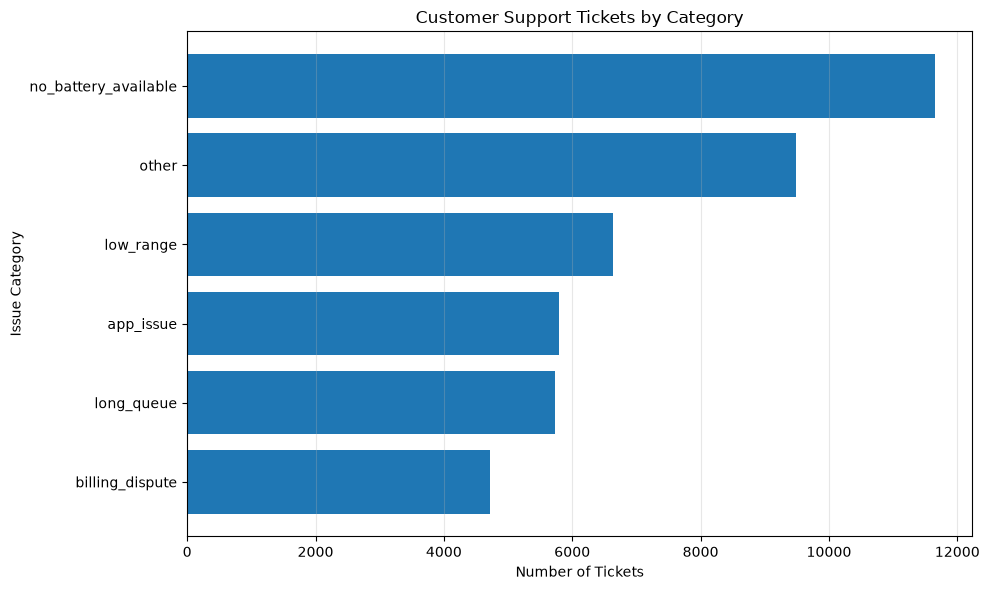

In [88]:
plt.figure(figsize=(10, 6))

plt.barh(
    ticket_analysis["category"],
    ticket_analysis["total_tickets"]
)

plt.title("Customer Support Tickets by Category")
plt.xlabel("Number of Tickets")
plt.ylabel("Issue Category")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [89]:
resolution_analysis = con.execute("""
    SELECT
        resolution_status,
        COUNT(*) AS total_tickets,
        ROUND(AVG(resolution_hours), 2)
            AS avg_resolution_hours,
        ROUND(AVG(csat_score), 2)
            AS avg_csat_score
    FROM support_tickets
    GROUP BY resolution_status
    ORDER BY total_tickets DESC
""").df()

display(resolution_analysis)

,resolution_status,total_tickets,avg_resolution_hours,avg_csat_score
0,resolved,37888,15.95,3.56
1,unresolved,5175,NaN,NaN
2,duplicate,937,NaN,NaN


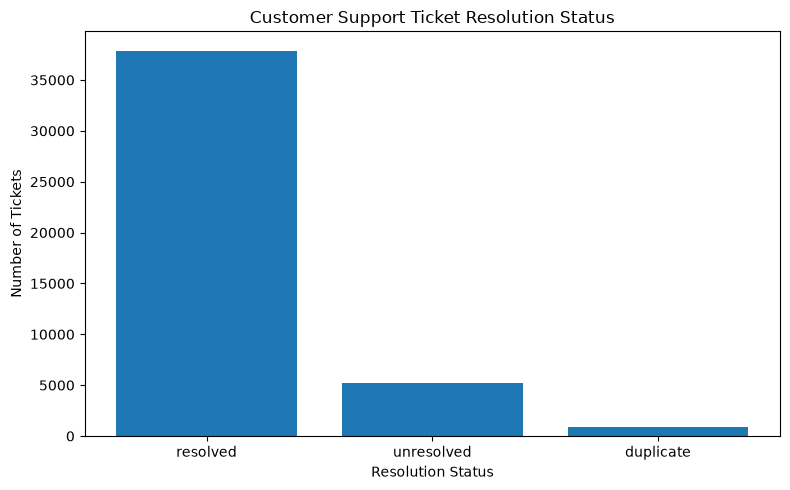

In [90]:
plt.figure(figsize=(8, 5))

plt.bar(
    resolution_analysis["resolution_status"],
    resolution_analysis["total_tickets"]
)

plt.title("Customer Support Ticket Resolution Status")
plt.xlabel("Resolution Status")
plt.ylabel("Number of Tickets")

plt.tight_layout()
plt.show()

In [91]:
# Unresolved tickets by category

unresolved_by_category = con.execute("""
    SELECT
        category,
        COUNT(*) AS unresolved_tickets
    FROM support_tickets
    WHERE resolution_status = 'unresolved'
    GROUP BY category
    ORDER BY unresolved_tickets DESC
""").df()

display(unresolved_by_category)

,category,unresolved_tickets
0,no_battery_available,1388
1,other,1125
2,low_range,770
3,app_issue,684
4,long_queue,675
5,billing_dispute,533


In [92]:
# Customer Satisfaction by Support Category

csat_analysis = con.execute("""
    SELECT
        category,
        COUNT(csat_score) AS total_rated_tickets,
        ROUND(AVG(csat_score), 2) AS avg_csat,
        ROUND(AVG(resolution_hours), 2) AS avg_resolution_hours
    FROM support_tickets
    WHERE csat_score IS NOT NULL
    GROUP BY category
    ORDER BY avg_csat
""").df()

display(csat_analysis)

,category,total_rated_tickets,avg_csat,avg_resolution_hours
0,long_queue,1994,3.51,14.20
1,low_range,2325,3.53,14.24
2,app_issue,1947,3.54,14.04
3,other,3246,3.57,14.32
4,billing_dispute,1620,3.57,14.09
5,no_battery_available,3997,3.60,13.99


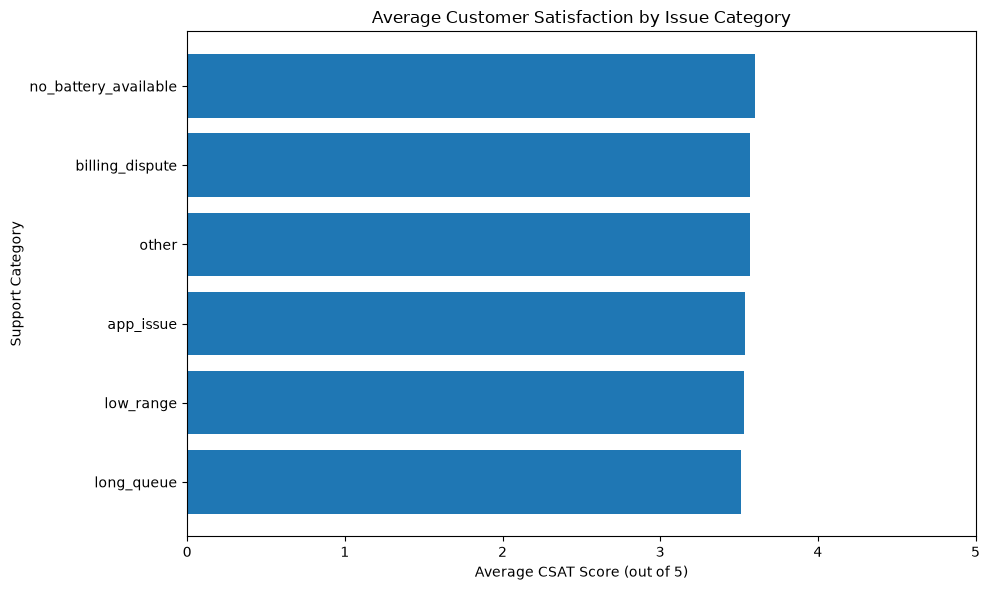

In [93]:
# Average Customer Satisfaction by Issue Category

plt.figure(figsize=(10, 6))

plt.barh(
    csat_analysis["category"],
    csat_analysis["avg_csat"]
)

plt.title("Average Customer Satisfaction by Issue Category")
plt.xlabel("Average CSAT Score (out of 5)")
plt.ylabel("Support Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

DuckDB configured successfully.
City context view created.
Processing 2024-01-01...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Processing 2024-02-01...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Processing 2024-03-01...


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Processing 2025-06-01...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Monthly processing completed.


,city,heat_condition,total_days,total_attempts,operational_failures,failure_rate_pct
0,Bengaluru,No Heat Alert,547,825327,23090,2.80
1,Delhi NCR,Heat Alert,62,96392,9109,9.45
2,Delhi NCR,No Heat Alert,485,672521,27088,4.03
3,Hyderabad,Heat Alert,16,20481,2100,10.25
4,Hyderabad,No Heat Alert,531,691449,28327,4.10
5,Jaipur,Heat Alert,72,73373,7606,10.37
6,Jaipur,No Heat Alert,475,414261,17071,4.12
7,Mumbai,No Heat Alert,547,530299,14441,2.72
8,Pune,No Heat Alert,547,552910,17127,3.10


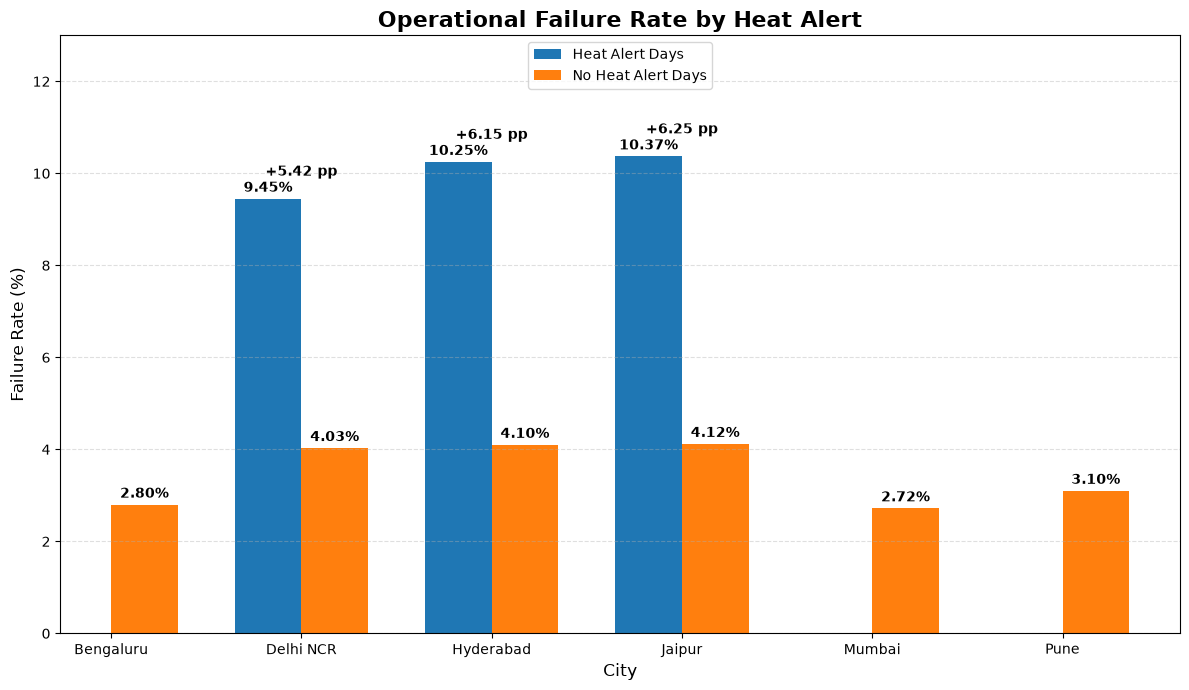

Heat-alert analysis completed successfully.
SVG graph saved.


In [104]:
# ============================================================
# HEAT ALERT VS NO HEAT ALERT FAILURE RATE
# MEMORY-EFFICIENT MONTHLY PROCESSING
# ============================================================

import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Configure DuckDB
# ------------------------------------------------------------

TEMP_DIR = os.path.join(DATA_DIR, "duckdb_temp")
os.makedirs(TEMP_DIR, exist_ok=True)

con.execute("SET memory_limit = '1GB'")
con.execute("SET threads = 1")
con.execute("SET preserve_insertion_order = false")

temp_path = TEMP_DIR.replace("\\", "/").replace("'", "''")
con.execute(f"SET temp_directory = '{temp_path}'")

# Recreate city_context because the database connection
# may have been reset earlier in the notebook.

CONTEXT_FILE = os.path.join(
    DATA_DIR, "city_daily_context.csv"
).replace("\\", "/")

con.execute(f"""
    CREATE OR REPLACE VIEW city_context AS
    SELECT *
    FROM read_csv_auto('{CONTEXT_FILE}', header=TRUE)
""")

print("DuckDB configured successfully.")
print("City context view created.")

# ------------------------------------------------------------
# STEP 2: Process swap data one month at a time
# ------------------------------------------------------------

monthly_results = []

months = pd.date_range(
    start="2024-01-01",
    end="2025-06-01",
    freq="MS"
)

for month in months:

    next_month = month + pd.DateOffset(months=1)

    start_date = month.strftime("%Y-%m-%d")
    end_date = next_month.strftime("%Y-%m-%d")

    print(f"Processing {start_date}...")

    query = f"""
        SELECT
            st.city,

            CASE
                WHEN c.heat_alert THEN 'Heat Alert'
                ELSE 'No Heat Alert'
            END AS heat_condition,

            COUNT(DISTINCT CAST(s.event_ts AS DATE))
                AS total_days,

            COUNT(*) AS total_attempts,

            COUNT(*) FILTER (
                WHERE s.event_type IN (
                    'failed_no_charged_battery',
                    'failed_system_error'
                )
            ) AS operational_failures

        FROM swap s

        JOIN stations st
            ON s.station_id = st.station_id

        JOIN city_context c
            ON st.city = c.city
            AND CAST(s.event_ts AS DATE) = CAST(c.date AS DATE)

        WHERE s.event_ts >= TIMESTAMP '{start_date}'
          AND s.event_ts < TIMESTAMP '{end_date}'

        GROUP BY
            st.city,
            c.heat_alert
    """

    month_result = con.execute(query).df()

    if not month_result.empty:
        monthly_results.append(month_result)

    del month_result
    gc.collect()

print("Monthly processing completed.")

# ------------------------------------------------------------
# STEP 3: Combine monthly results
# ------------------------------------------------------------

if not monthly_results:
    raise ValueError(
        "No results found. Check the swap, stations, "
        "and city_context views."
    )

all_results = pd.concat(
    monthly_results,
    ignore_index=True
)

context_failure_analysis = (
    all_results
    .groupby(["city", "heat_condition"], as_index=False)
    .agg(
        total_days=("total_days", "sum"),
        total_attempts=("total_attempts", "sum"),
        operational_failures=("operational_failures", "sum")
    )
)

context_failure_analysis["failure_rate_pct"] = (
    100
    * context_failure_analysis["operational_failures"]
    / context_failure_analysis["total_attempts"]
).round(2)

context_failure_analysis = (
    context_failure_analysis
    .sort_values(["city", "heat_condition"])
    .reset_index(drop=True)
)

display(context_failure_analysis)

# ------------------------------------------------------------
# STEP 4: Prepare graph data
# ------------------------------------------------------------

cities = [
    "Bengaluru",
    "Delhi NCR",
    "Hyderabad",
    "Jaipur",
    "Mumbai",
    "Pune"
]

heat_rates = (
    context_failure_analysis[
        context_failure_analysis["heat_condition"] == "Heat Alert"
    ]
    .set_index("city")["failure_rate_pct"]
)

no_heat_rates = (
    context_failure_analysis[
        context_failure_analysis["heat_condition"] == "No Heat Alert"
    ]
    .set_index("city")["failure_rate_pct"]
)

heat_values = [
    heat_rates.get(city, np.nan)
    for city in cities
]

no_heat_values = [
    no_heat_rates.get(city, np.nan)
    for city in cities
]

# ------------------------------------------------------------
# STEP 5: Create graph
# ------------------------------------------------------------

x = np.arange(len(cities))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(
    x - width / 2,
    heat_values,
    width,
    label="Heat Alert Days"
)

bars2 = ax.bar(
    x + width / 2,
    no_heat_values,
    width,
    label="No Heat Alert Days"
)

# Add percentage labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        if not np.isnan(height):
            ax.annotate(
                f"{height:.2f}%",
                xy=(
                    bar.get_x() + bar.get_width() / 2,
                    height
                ),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                fontsize=10,
                fontweight="bold"
            )

# Add percentage-point differences
for i, city in enumerate(cities):

    if (
        not np.isnan(heat_values[i])
        and not np.isnan(no_heat_values[i])
    ):
        difference = heat_values[i] - no_heat_values[i]

        ax.annotate(
            f"+{difference:.2f} pp",
            xy=(
                i,
                max(heat_values[i], no_heat_values[i]) + 0.5
            ),
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

# Format graph
ax.set_title(
    "Operational Failure Rate by Heat Alert",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Failure Rate (%)", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(cities)

ax.set_ylim(0, 13)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save as SVG
plt.savefig(
    "heat_alert_failure_comparison.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("Heat-alert analysis completed successfully.")
print("SVG graph saved.")

# Conclusion

We analyzed millions of battery-swapping records to understand battery performance, station failures, customer experience, and revenue.

Our findings help VoltRelay Energy identify problems, improve services, reduce waiting times, and provide a better experience for customers.

**Our goal:** Use data analytics to make battery swapping more reliable and efficient.